In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# Import the file
df = pd.read_excel('Games_final.xlsx')


In [58]:
df.columns

Index(['Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [59]:
# Identify the unique platforms

platforms = sorted(df["Platform"].unique())
platforms

['2600',
 '3DO',
 '3DS',
 'DC',
 'DS',
 'GB',
 'GBA',
 'GC',
 'GEN',
 'GG',
 'N64',
 'NES',
 'NG',
 'PC',
 'PCFX',
 'PS',
 'PS2',
 'PS3',
 'PS4',
 'PSP',
 'PSV',
 'SAT',
 'SCD',
 'SNES',
 'TG16',
 'WS',
 'Wii',
 'WiiU',
 'X360',
 'XB',
 'XOne']

In [60]:
platform_map = {
    # PlayStation
    "PS": "PlayStation",
    "PS2": "PlayStation",
    "PS3": "PlayStation",
    "PS4": "PlayStation",
    "PSP": "PlayStation",
    "PSV": "PlayStation",

    # Xbox
    "XB": "Xbox",
    "X360": "Xbox",
    "XOne": "Xbox",

    # Nintendo Home
    "NES": "Nintendo",
    "SNES": "Nintendo",
    "N64": "Nintendo",
    "GC": "Nintendo",
    "Wii": "Nintendo",
    "WiiU": "Nintendo",
    "Switch": "Nintendo",

    # Nintendo Handheld
    "GB": "Nintendo",
    "GBA": "Nintendo",
    "DS": "Nintendo",
    "3DS": "Nintendo",

    # PC
    "PC": "PC",

    # Sega
    "GEN": "Sega",
    "SCD": "Sega",
    "SAT": "Sega",
    "DC": "Sega",

    # Other
    "2600": "Atari",
    "WS": "Other",
    "NG": "Other",
    "TG16": "Other",
    "3DO": "Other",
    "GG": "Other",
    "PCFX": "Other"
}

In [61]:
df["Platform_Family"] = df["Platform"].map(platform_map)


In [62]:
df[["Platform", "Platform_Family"]].drop_duplicates()

,Platform,Platform_Family
0,Wii,Nintendo
1,NES,Nintendo
4,GB,Nintendo
6,DS,Nintendo
15,X360,Xbox
16,PS3,PlayStation
17,PS2,PlayStation
18,SNES,Nintendo
25,GBA,Nintendo
32,3DS,Nintendo


In [63]:
df.to_csv("vgsales_input_platform_families.csv", index=False)

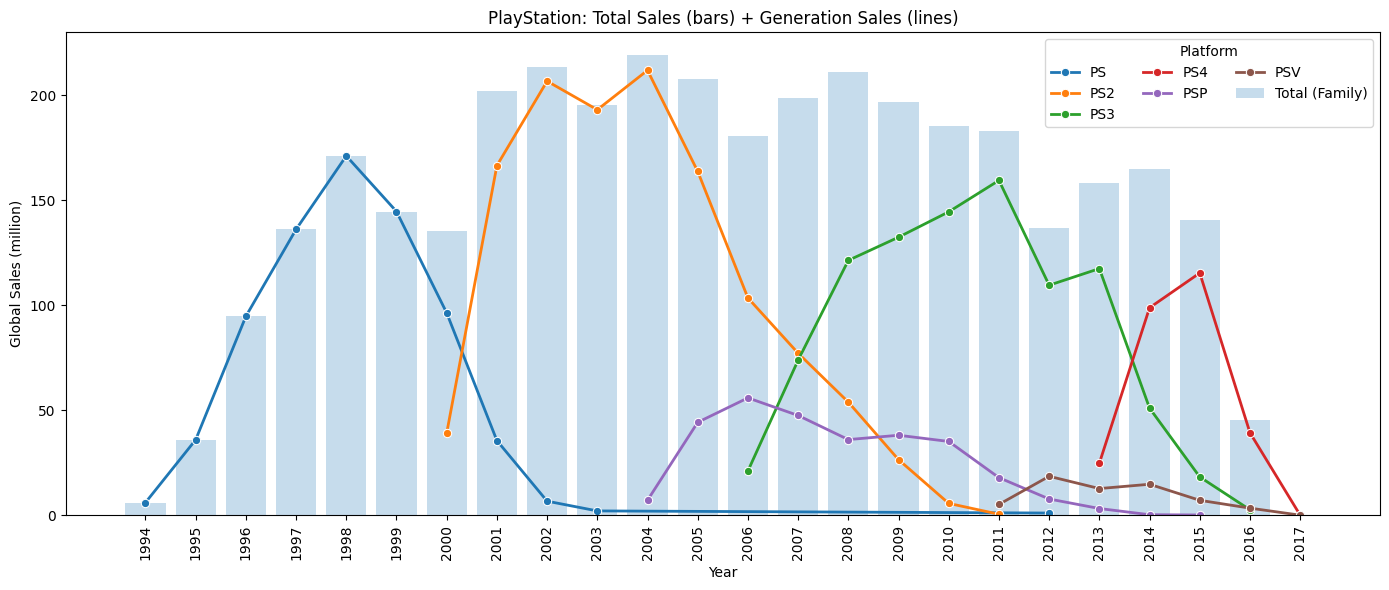

In [64]:
ps_platforms = ["PS", "PS2", "PS3", "PS4", "PSP", "PSV"]

# aggregate totals per year (numeric Year)
total = (
    df.loc[df["Platform"].isin(ps_platforms) & df["Year"].notna(), ["Year", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby("Year", as_index=False)["Global_Sales"]
      .sum()
      .sort_values("Year")
)

# aggregate per generation per year
by_gen = (
    df.loc[df["Platform"].isin(ps_platforms) & df["Year"].notna(), ["Year", "Platform", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby(["Year", "Platform"], as_index=False)["Global_Sales"]
      .sum()
      .sort_values(["Platform", "Year"])
)

fig, ax = plt.subplots(figsize=(14, 6))

# background bars = total PlayStation family sales per year
ax.bar(total["Year"], total["Global_Sales"], alpha=0.25, width=0.8, label="Total (Family)")

# lines = sales per generation per year
sns.lineplot(
    data=by_gen,
    x="Year",
    y="Global_Sales",
    hue="Platform",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("PlayStation: Total Sales (bars) + Generation Sales (lines)")
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (million)")

# show every year (can get crowded; adjust if needed)
years = total["Year"].to_numpy()
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90)

ax.legend(title="Platform", ncol=3, frameon=True)
plt.tight_layout()
plt.show()

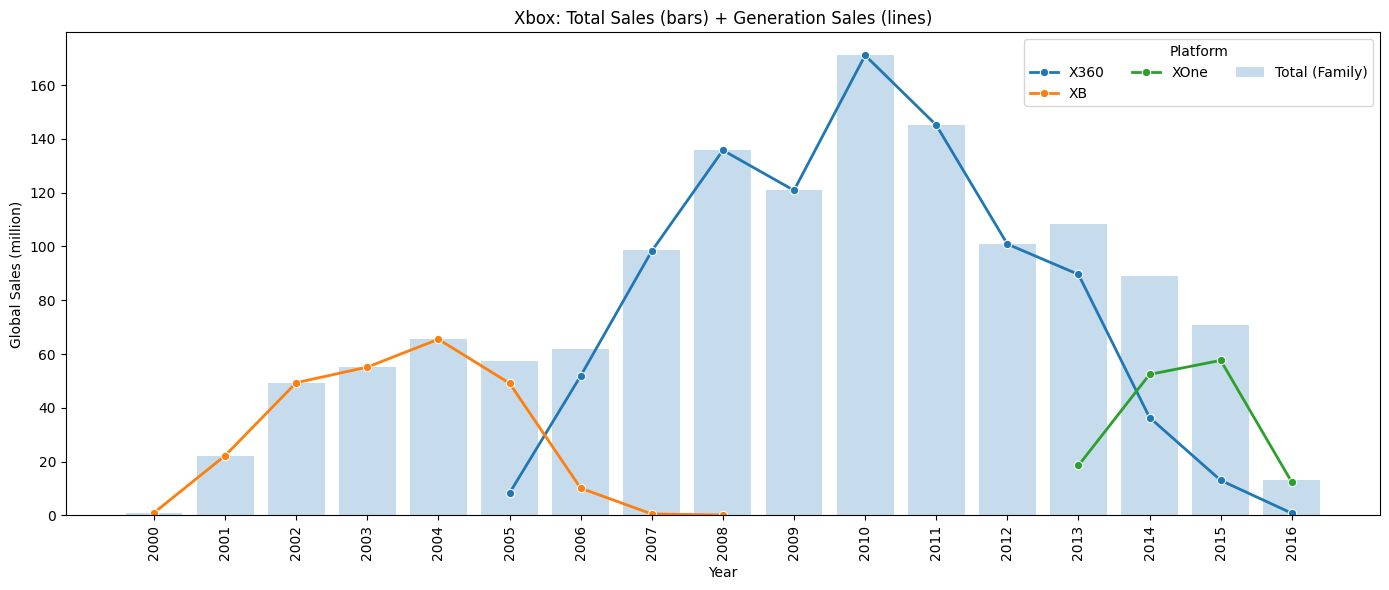

In [65]:
# XBOX: Total (bars) + generations (lines)
platforms = ["XB", "X360", "XOne"]
title = "Xbox"

total = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby("Year", as_index=False)["Global_Sales"]
      .sum()
      .sort_values("Year")
)

by_gen = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Platform", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby(["Year", "Platform"], as_index=False)["Global_Sales"]
      .sum()
      .sort_values(["Platform", "Year"])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(total["Year"], total["Global_Sales"], alpha=0.25, width=0.8, label="Total (Family)")

sns.lineplot(data=by_gen, x="Year", y="Global_Sales", hue="Platform",
             marker="o", linewidth=2, ax=ax)

ax.set_title(f"{title}: Total Sales (bars) + Generation Sales (lines)")
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (million)")

years = total["Year"].to_numpy()
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90)

ax.legend(title="Platform", ncol=3, frameon=True)
plt.tight_layout()
plt.show()

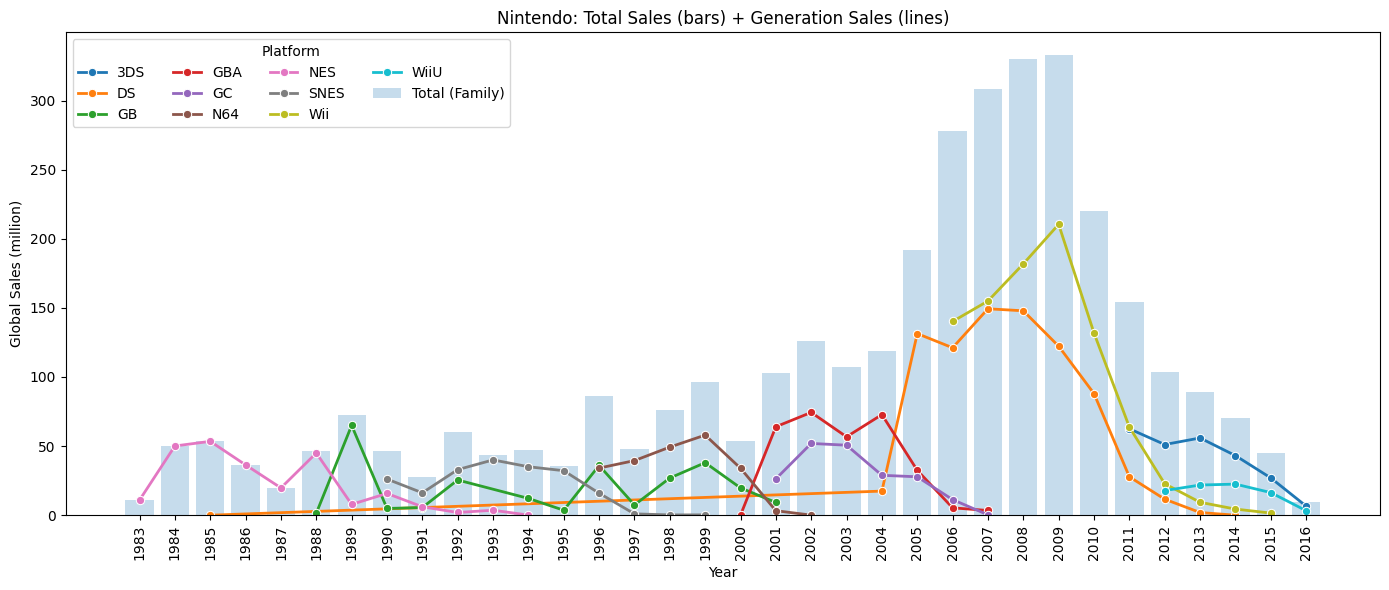

In [66]:
# NINTENDO: Total (bars) + generations (lines)
platforms = ["NES", "SNES", "N64", "GC", "Wii", "WiiU", "Switch", "GB", "GBA", "DS", "3DS"]
title = "Nintendo"

total = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby("Year", as_index=False)["Global_Sales"]
      .sum()
      .sort_values("Year")
)

by_gen = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Platform", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby(["Year", "Platform"], as_index=False)["Global_Sales"]
      .sum()
      .sort_values(["Platform", "Year"])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(total["Year"], total["Global_Sales"], alpha=0.25, width=0.8, label="Total (Family)")

sns.lineplot(data=by_gen, x="Year", y="Global_Sales", hue="Platform",
             marker="o", linewidth=2, ax=ax)

ax.set_title(f"{title}: Total Sales (bars) + Generation Sales (lines)")
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (million)")

years = total["Year"].to_numpy()
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90)

ax.legend(title="Platform", ncol=4, frameon=True)
plt.tight_layout()
plt.show()

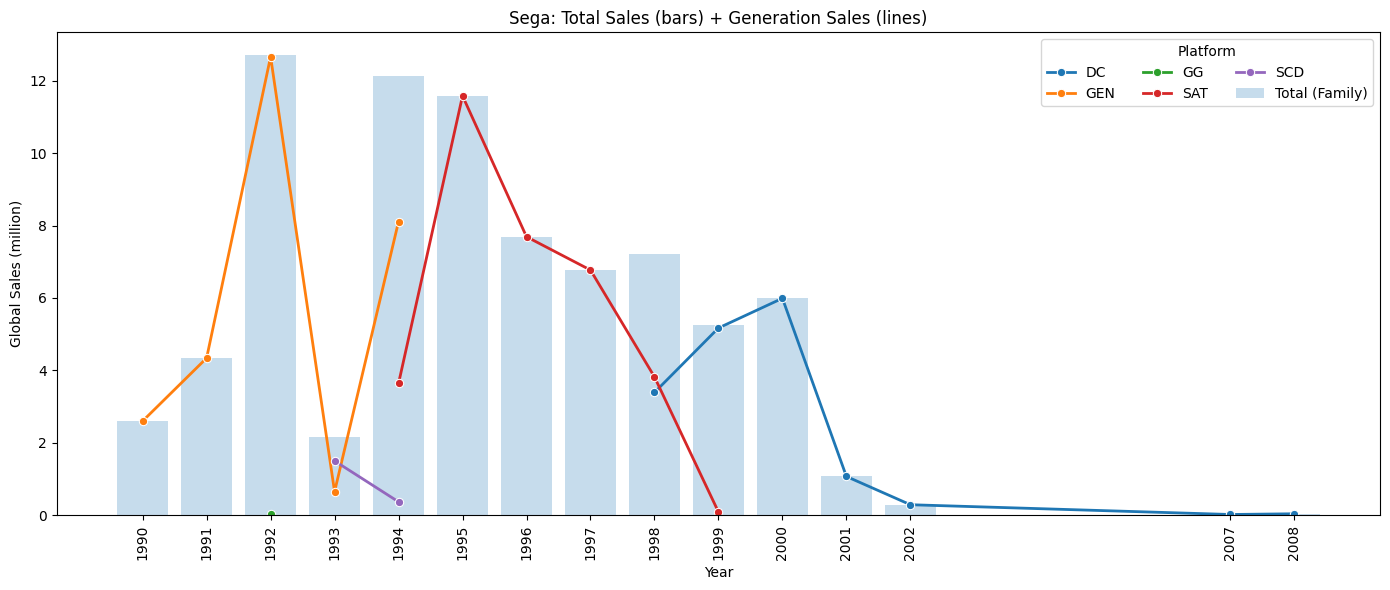

In [67]:
# SEGA: Total (bars) + generations (lines)
platforms = ["GEN", "SCD", "SAT", "DC", "GG"]
title = "Sega"

total = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby("Year", as_index=False)["Global_Sales"]
      .sum()
      .sort_values("Year")
)

by_gen = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Platform", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby(["Year", "Platform"], as_index=False)["Global_Sales"]
      .sum()
      .sort_values(["Platform", "Year"])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(total["Year"], total["Global_Sales"], alpha=0.25, width=0.8, label="Total (Family)")

sns.lineplot(data=by_gen, x="Year", y="Global_Sales", hue="Platform",
             marker="o", linewidth=2, ax=ax)

ax.set_title(f"{title}: Total Sales (bars) + Generation Sales (lines)")
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (million)")

years = total["Year"].to_numpy()
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90)

ax.legend(title="Platform", ncol=3, frameon=True)
plt.tight_layout()
plt.show()

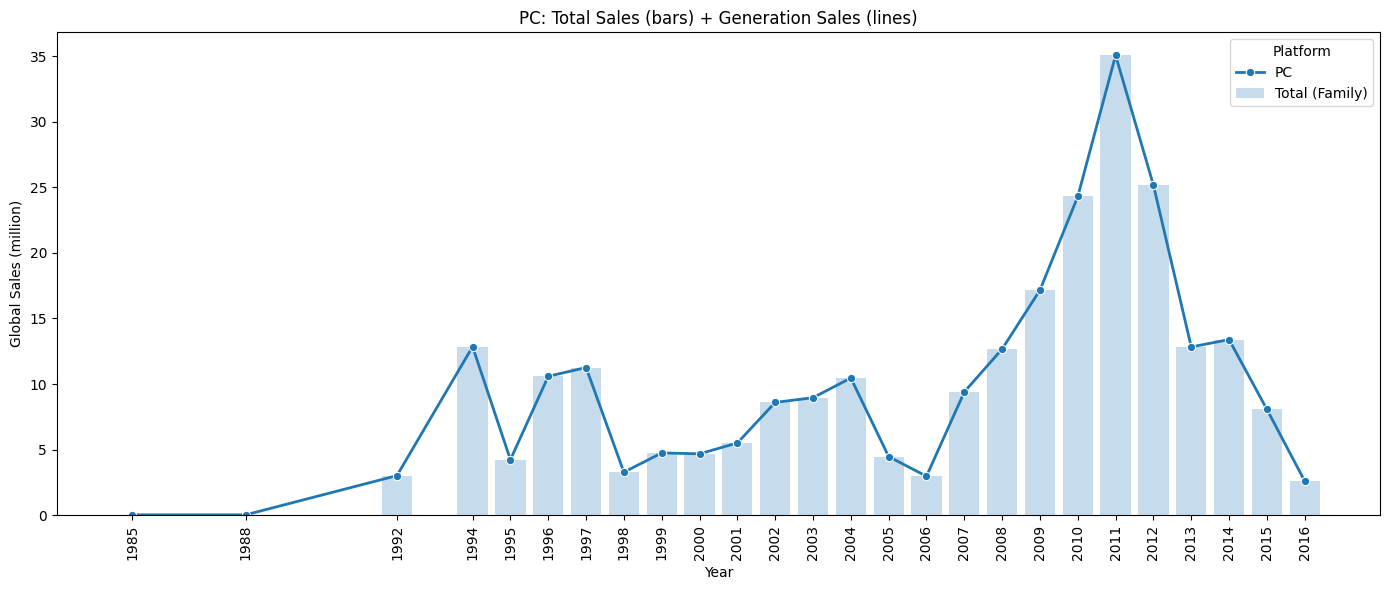

In [68]:
# PC: Total (bars) + generations (lines) (only one generation: PC)
platforms = ["PC"]
title = "PC"

total = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby("Year", as_index=False)["Global_Sales"]
      .sum()
      .sort_values("Year")
)

by_gen = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Platform", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby(["Year", "Platform"], as_index=False)["Global_Sales"]
      .sum()
      .sort_values(["Platform", "Year"])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(total["Year"], total["Global_Sales"], alpha=0.25, width=0.8, label="Total (Family)")

sns.lineplot(data=by_gen, x="Year", y="Global_Sales", hue="Platform",
             marker="o", linewidth=2, ax=ax)

ax.set_title(f"{title}: Total Sales (bars) + Generation Sales (lines)")
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (million)")

years = total["Year"].to_numpy()
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90)

ax.legend(title="Platform", frameon=True)
plt.tight_layout()
plt.show()

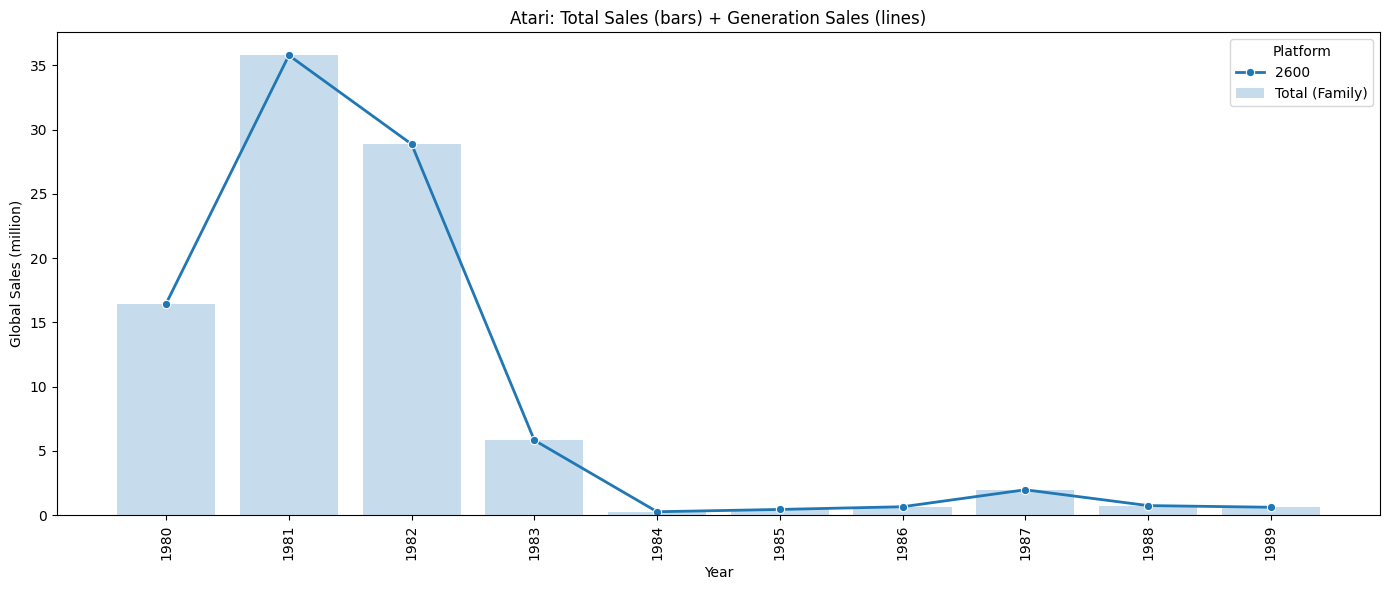

In [69]:
# ATARI: Total (bars) + generations (lines) (only one generation: 2600)
platforms = ["2600"]
title = "Atari"

total = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby("Year", as_index=False)["Global_Sales"]
      .sum()
      .sort_values("Year")
)

by_gen = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Platform", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby(["Year", "Platform"], as_index=False)["Global_Sales"]
      .sum()
      .sort_values(["Platform", "Year"])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(total["Year"], total["Global_Sales"], alpha=0.25, width=0.8, label="Total (Family)")

sns.lineplot(data=by_gen, x="Year", y="Global_Sales", hue="Platform",
             marker="o", linewidth=2, ax=ax)

ax.set_title(f"{title}: Total Sales (bars) + Generation Sales (lines)")
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (million)")

years = total["Year"].to_numpy()
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90)

ax.legend(title="Platform", frameon=True)
plt.tight_layout()
plt.show()

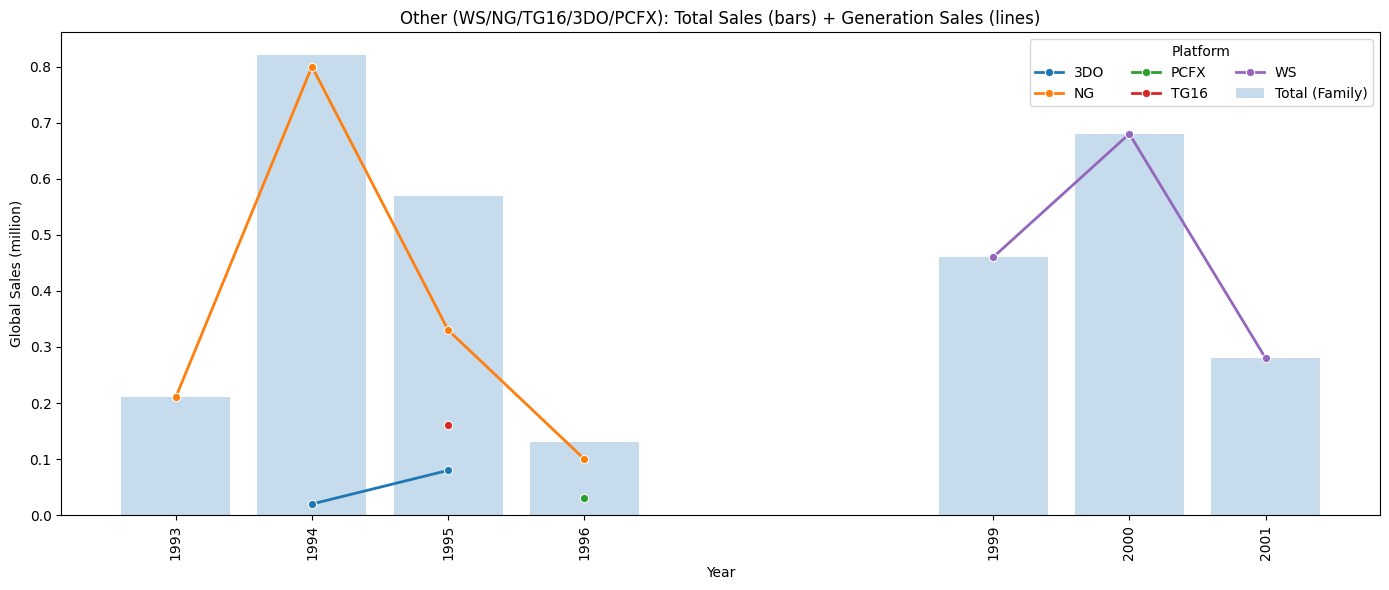

In [70]:
# OTHER: Total (bars) + generations (lines)
platforms = ["WS", "NG", "TG16", "3DO", "PCFX"]
title = "Other (WS/NG/TG16/3DO/PCFX)"

total = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby("Year", as_index=False)["Global_Sales"]
      .sum()
      .sort_values("Year")
)

by_gen = (
    df.loc[df["Platform"].isin(platforms) & df["Year"].notna(), ["Year", "Platform", "Global_Sales"]]
      .assign(Year=lambda x: x["Year"].astype(int))
      .groupby(["Year", "Platform"], as_index=False)["Global_Sales"]
      .sum()
      .sort_values(["Platform", "Year"])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(total["Year"], total["Global_Sales"], alpha=0.25, width=0.8, label="Total (Family)")

sns.lineplot(data=by_gen, x="Year", y="Global_Sales", hue="Platform",
             marker="o", linewidth=2, ax=ax)

ax.set_title(f"{title}: Total Sales (bars) + Generation Sales (lines)")
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (million)")

years = total["Year"].to_numpy()
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90)

ax.legend(title="Platform", ncol=3, frameon=True)
plt.tight_layout()
plt.show()

## Training a Regression Model to forecast sales

In [71]:
# Preperation for training: Merge all platform with <50 observations into "Other"

platform_counts = df["Platform"].value_counts()

valid_platforms = platform_counts[platform_counts >= 50].index

# create training platform column
df["Platform_train"] = df["Platform"].where(
    df["Platform"].isin(valid_platforms),
    "Other"
)

# quick check
df["Platform_train"].value_counts()

Platform_train
PS2      2132
DS       2131
PS3      1304
Wii      1295
X360     1235
PSP      1198
PS       1191
PC        939
XB        804
GBA       788
GC        542
3DS       499
PSV       410
PS4       336
N64       316
SNES      239
XOne      213
SAT       173
WiiU      143
2600      119
GB         98
NES        98
Other      58
DC         52
Name: count, dtype: int64

In [72]:
# select relevant columns for training

cols = ["Platform", "Year", "Genre", "Publisher", "Global_Sales"]
df = df[cols].dropna(subset=["Platform", "Year", "Genre", "Publisher", "Global_Sales"]).copy()
df["Year"] = df["Year"].astype(int)

# target (log)
y = np.log1p(df["Global_Sales"])

X = df[["Platform", "Year", "Genre", "Publisher"]]

In [73]:
# 2) train/test split (time-aware to avoid leakage)
# choose a cutoff year; here: last ~3 years in dataset become test
cutoff = df["Year"].quantile(0.95)
cutoff = int(cutoff)

train_mask = df["Year"] < cutoff
test_mask = ~train_mask

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

cutoff, X_train.shape, X_test.shape

(2015, (15354, 4), (959, 4))

In [74]:
# 3) preprocessing: one-hot encode categoricals, scale numeric year
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV

cat_cols = ["Platform", "Genre", "Publisher"]
num_cols = ["Year"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ],
    remainder="drop"
)

# 4) model: Ridge with cross-validated alpha (regularization strength)
alphas = np.logspace(-3, 3, 50)

model = RidgeCV(alphas=alphas, cv=5)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", model)
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [75]:
# 5) train
pipe.fit(X_train, y_train)

best_alpha = pipe.named_steps["model"].alpha_
best_alpha# 5) train
pipe.fit(X_train, y_train)

best_alpha = pipe.named_steps["model"].alpha_
best_alpha

np.float64(3.5564803062231287)

In [76]:
# 6) predict + evaluate (on log scale)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = pipe.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
mae_log = mean_absolute_error(y_test, y_pred)
r2_log = r2_score(y_test, y_pred)

rmse_log, mae_log, r2_log

/opt/anaconda3/envs/ASDA_2025_Group_1_Portfolio_new/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(np.float64(0.32656473249701345), 0.24019772244296936, 0.08860851626346267)

In [77]:
# 7) optional: evaluate in original sales scale (interpretability)
# note: metrics on original scale are dominated by blockbusters; keep log metrics as primary
sales_true = np.expm1(y_test)
sales_pred = np.expm1(y_pred)

rmse_sales = np.sqrt(mean_squared_error(sales_true, sales_pred))
mae_sales = mean_absolute_error(sales_true, sales_pred)
r2_sales = r2_score(sales_true, sales_pred)

rmse_sales, mae_sales, r2_sales

(np.float64(0.8341691916489269), 0.4022409643461541, 0.15598570274509538)

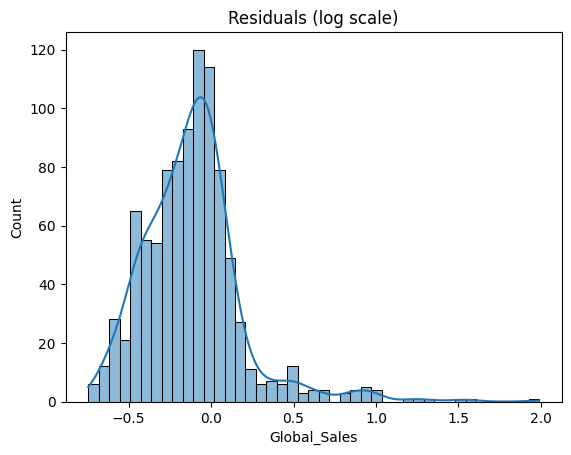

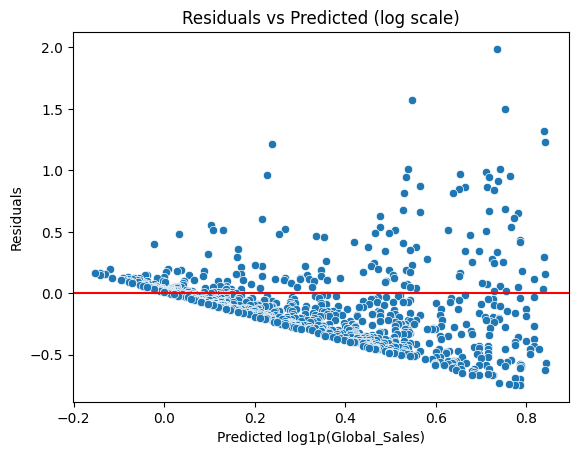

In [78]:
# 8) quick residual diagnostics (log scale)
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residuals (log scale)")
plt.show()

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red")
plt.title("Residuals vs Predicted (log scale)")
plt.xlabel("Predicted log1p(Global_Sales)")
plt.ylabel("Residuals")
plt.show()

## Predicting from the test data to evaluate model performance

In [79]:
# Predict on test set (log scale)
y_pred_log = pipe.predict(X_test)

# Back-transform to original sales scale
y_test_sales = np.expm1(y_test)
y_pred_sales = np.expm1(y_pred_log)

# Absolute + relative errors (original scale)
abs_err = np.abs(y_test_sales - y_pred_sales)
pct_err = abs_err / np.clip(y_test_sales, 1e-9, None)  # avoid divide-by-zero

# Summary metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

rmse_sales = np.sqrt(mean_squared_error(y_test_sales, y_pred_sales))
mae_sales = mean_absolute_error(y_test_sales, y_pred_sales)
r2_sales = r2_score(y_test_sales, y_pred_sales)

print("=== Test Set Performance of Regression ===\n")


print("LOG SCALE:")
print(f"  RMSE: {rmse_log:.4f} | MAE: {mae_log:.4f} | R2: {r2_log:.4f}")

print("\nORIGINAL SALES SCALE:")
print(f"  RMSE: {rmse_sales:.4f} | MAE: {mae_sales:.4f} | R2: {r2_sales:.4f}")

# Precision-style reporting (robust percentiles)
print("\nABS ERROR (sales) percentiles:")
print(abs_err.quantile([0.5, 0.75, 0.9, 0.95]).to_string())

print("\nPERCENT ERROR percentiles (only where true sales > 0.1):")
mask = y_test_sales > 0.1
print(pct_err[mask].quantile([0.5, 0.75, 0.9, 0.95]).to_string())

# Show worst predictions (largest absolute errors)
results = X_test.copy()
results["true_sales"] = y_test_sales.values
results["pred_sales"] = y_pred_sales
results["abs_err"] = abs_err.values
results["pct_err"] = pct_err.values

results.sort_values("abs_err", ascending=False).head(20)


=== Test Set Performance of Regression ===

LOG SCALE:
  RMSE: 0.3266 | MAE: 0.2402 | R2: 0.0886

ORIGINAL SALES SCALE:
  RMSE: 0.8342 | MAE: 0.4022 | R2: 0.1560

ABS ERROR (sales) percentiles:
0.50    0.226062
0.75    0.505470
0.90    0.802053
0.95    1.004832

PERCENT ERROR percentiles (only where true sales > 0.1):
0.50    0.704845
0.75    1.377703
0.90    3.204151
0.95    4.316639


/opt/anaconda3/envs/ASDA_2025_Group_1_Portfolio_new/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Platform,Year,Genre,Publisher,true_sales,pred_sales,abs_err,pct_err
33,PS4,2015,Shooter,Activision,14.24,1.084456,13.155544,0.923844
77,PS4,2015,Sports,Electronic Arts,8.49,1.123293,7.366707,0.867692
101,XOne,2015,Shooter,Activision,7.30,0.728854,6.571146,0.900157
92,PS4,2015,Shooter,Electronic Arts,7.67,1.311038,6.358962,0.829069
109,PS4,2015,Role-Playing,Bethesda Softworks,6.96,1.318504,5.641496,0.810560
221,PS4,2016,Sports,Electronic Arts,4.77,1.100117,3.669883,0.769367
243,PS4,2015,Action,Sony Computer Entertainment,4.47,1.033167,3.436833,0.768866
235,WiiU,2015,Shooter,Nintendo,4.57,1.145482,3.424518,0.749348
260,XOne,2015,Shooter,Microsoft Game Studios,4.26,1.046643,3.213357,0.754309
287,XOne,2015,Role-Playing,Bethesda Softworks,4.09,0.922974,3.167026,0.774334


#### Model Evaluation

The model’s performance is weak. On the log scale, the R² of approximately 0.09 means that the model explains only about nine percent of the variance in log-transformed sales. On the original sales scale, the R² of roughly 0.16 is still low, indicating that most of the variation in sales remains unexplained. The median absolute error is around 0.23 million units, and the median percentage error is about seventy percent, which implies that for half of the games the prediction deviates by roughly seventy percent from the true sales. The upper error percentiles are even larger, showing that the model struggles particularly with more extreme outcomes.

The main reason for this limited performance is that the feature set is too weak to capture the true drivers of game sales. Platform, year, genre, and publisher provide only coarse structural information. They do not account for key determinants such as franchise strength, marketing intensity, review quality, brand reputation, or network effects. Video game sales also follow a heavy-tailed, superstar-like distribution, where a small number of blockbusters generate disproportionate sales. Linear models, especially with only additive effects, have difficulty capturing these nonlinear and interaction-driven dynamics. In short, the model is statistically coherent but the available predictors contain insufficient signal to achieve strong predictive performance.

In [80]:
## Gradient Boosting Model 



In [81]:
cols = ["Platform", "Year", "Genre", "Publisher", "Global_Sales"]
df = df[cols].dropna().copy()
df["Year"] = df["Year"].astype(int)

y = np.log1p(df["Global_Sales"])
X = df[["Platform", "Year", "Genre", "Publisher"]]

In [82]:
cutoff = int(df["Year"].quantile(0.95))

train_mask = df["Year"] < cutoff
test_mask = ~train_mask

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

cat_cols = ["Platform", "Genre", "Publisher"]
num_cols = ["Year"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

In [84]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [85]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_log = pipe.predict(X_test)

# Log-scale metrics
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

# Back-transform
y_test_sales = np.expm1(y_test)
y_pred_sales = np.expm1(y_pred_log)

rmse_sales = np.sqrt(mean_squared_error(y_test_sales, y_pred_sales))
mae_sales = mean_absolute_error(y_test_sales, y_pred_sales)
r2_sales = r2_score(y_test_sales, y_pred_sales)

print("=== Gradient Boosting Performance ===\n")

print("LOG SCALE:")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE  (log): {mae_log:.4f}")
print(f"R²   (log): {r2_log:.4f}")

print("\nORIGINAL SALES SCALE:")
print(f"RMSE (sales): {rmse_sales:.4f}")
print(f"MAE  (sales): {mae_sales:.4f}")
print(f"R²   (sales): {r2_sales:.4f}")

=== Gradient Boosting Performance ===

LOG SCALE:
RMSE (log): 0.3310
MAE  (log): 0.2410
R²   (log): 0.0640

ORIGINAL SALES SCALE:
RMSE (sales): 0.8276
MAE  (sales): 0.4072
R²   (sales): 0.1692


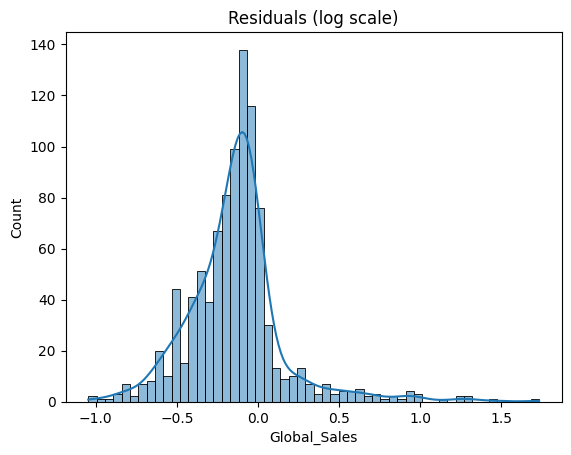

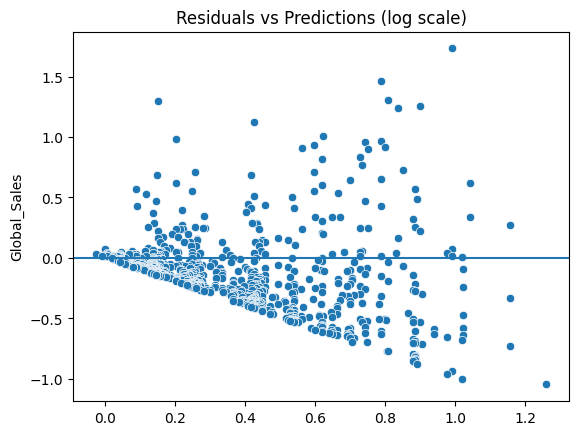

In [86]:
residuals = y_test - y_pred_log

sns.histplot(residuals, kde=True)
plt.title("Residuals (log scale)")
plt.show()

sns.scatterplot(x=y_pred_log, y=residuals)
plt.axhline(0)
plt.title("Residuals vs Predictions (log scale)")
plt.show()

## Predict on test set (log scale) using Gradient Boosting

In [87]:
# Predict (log scale)
y_pred_log = pipe.predict(X_test)

# Convert back to original sales scale
y_test_sales = np.expm1(y_test)
y_pred_sales = np.expm1(y_pred_log)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Log-scale metrics
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

# Original-scale metrics
rmse_sales = np.sqrt(mean_squared_error(y_test_sales, y_pred_sales))
mae_sales = mean_absolute_error(y_test_sales, y_pred_sales)
r2_sales = r2_score(y_test_sales, y_pred_sales)

print("=== Test Set Performance ===\n")

print("LOG SCALE:")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE  (log): {mae_log:.4f}")
print(f"R²   (log): {r2_log:.4f}")

print("\nORIGINAL SALES SCALE:")
print(f"RMSE (sales): {rmse_sales:.4f}")
print(f"MAE  (sales): {mae_sales:.4f}")
print(f"R²   (sales): {r2_sales:.4f}")

=== Test Set Performance ===

LOG SCALE:
RMSE (log): 0.3310
MAE  (log): 0.2410
R²   (log): 0.0640

ORIGINAL SALES SCALE:
RMSE (sales): 0.8276
MAE  (sales): 0.4072
R²   (sales): 0.1692


## Model for clustering series of games together

In [88]:
# Reimport df for clustering (It got modified when running the model)
df = pd.read_excel("Games_final.xlsx")

In [89]:
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity

needed = ["Name", "Year", "Platform", "Genre", "Publisher", "Global_Sales"]
df = df[needed].dropna().copy()
df["Year"] = df["Year"].astype(int)

# 2) Time-aware split (same principle as before)
cutoff = int(df["Year"].quantile(0.90))
train_mask = df["Year"] < cutoff
test_mask = ~train_mask

train_names = df.loc[train_mask, "Name"].astype(str).tolist()
test_names  = df.loc[test_mask, "Name"].astype(str).tolist()

# 3) Create embeddings (sentence-transformers)
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer("all-MiniLM-L6-v2")

train_emb = emb_model.encode(train_names, normalize_embeddings=True, show_progress_bar=True)
test_emb  = emb_model.encode(test_names,  normalize_embeddings=True, show_progress_bar=True)


Batches: 100%|██████████| 66/66 [00:01<00:00, 62.05it/s]


In [90]:

# 4) DBSCAN clustering on TRAIN embeddings only
# eps is similarity-radius related (with cosine distance). You will likely need to tune eps.
db = DBSCAN(eps=0.22, min_samples=4, metric="cosine")
train_labels = db.fit_predict(train_emb)

# 5) Build cluster centroids for labels >= 0
# (noise points are label = -1)
unique_labels = sorted([l for l in set(train_labels) if l != -1])

centroids = []
centroid_labels = []
for lab in unique_labels:
    members = train_emb[train_labels == lab]
    centroids.append(members.mean(axis=0))
    centroid_labels.append(lab)

centroids = np.vstack(centroids) if len(centroids) > 0 else np.empty((0, train_emb.shape[1]))

# 6) Assign TEST points by nearest centroid (cosine similarity)
# If similarity is below a threshold -> treat as noise (-1)
sim_threshold = 0.60  # tune this; higher = stricter assignment

if centroids.shape[0] == 0:
    test_labels = np.full(len(test_emb), -1)
else:
    sims = cosine_similarity(test_emb, centroids)  # (n_test, n_clusters)
    best_idx = sims.argmax(axis=1)
    best_sim = sims.max(axis=1)
    test_labels = np.where(best_sim >= sim_threshold, np.array(centroid_labels)[best_idx], -1)

# 7) Write labels back to df
df.loc[train_mask, "Series_Cluster"] = train_labels
df.loc[test_mask, "Series_Cluster"] = test_labels
df["Series_Cluster"] = df["Series_Cluster"].astype(int)

# 8) Quick sanity checks
print("Cutoff year:", cutoff)
print("Train clusters (excluding noise):", len(unique_labels))
print("Train noise share:", (train_labels == -1).mean())
print("Test noise share:", (test_labels == -1).mean())

# Show top clusters by size (train)
train_cluster_sizes = (
    pd.Series(train_labels)
    .value_counts()
    .rename_axis("cluster")
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
train_cluster_sizes.head(15)

Cutoff year: 2013
Train clusters (excluding noise): 704
Train noise share: 0.5595305032330615
Test noise share: 0.5002398081534772


,cluster,count
0,-1,7961
1,12,162
2,86,131
3,33,87
4,170,71
5,352,70
6,333,62
7,27,56
8,0,54
9,191,53


In [91]:
df.columns

Index(['Name', 'Year', 'Platform', 'Genre', 'Publisher', 'Global_Sales',
       'Series_Cluster'],
      dtype='object')

In [92]:
df[df["Series_Cluster"] == 170]

,Name,Year,Platform,Genre,Publisher,Global_Sales,Series_Cluster
942,NCAA Football 06,2005,PS2,Sports,Electronic Arts,1.84,170
1056,NCAA Football 07,2006,PS2,Sports,Electronic Arts,1.70,170
1095,NCAA Football 2004,2003,PS2,Sports,Electronic Arts,1.67,170
1131,NCAA Football 2005,2004,PS2,Sports,Electronic Arts,1.62,170
1181,NCAA Football 2002,2001,PS2,Sports,Electronic Arts,1.57,170
...,...,...,...,...,...,...,...
8616,NCAA Football 2004,2003,GC,Sports,Electronic Arts,0.15,170
8642,NCAA GameBreaker 2001,2000,PS2,Sports,Sony Computer Entertainment,0.15,170
9025,NCAA Basketball Final Four 97,1997,PS,Sports,Mindscape,0.14,170
10773,NCAA March Madness 08,2007,PS3,Sports,Electronic Arts,0.09,170


/opt/anaconda3/envs/ASDA_2025_Group_1_Portfolio_new/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/ASDA_2025_Group_1_Portfolio_new/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


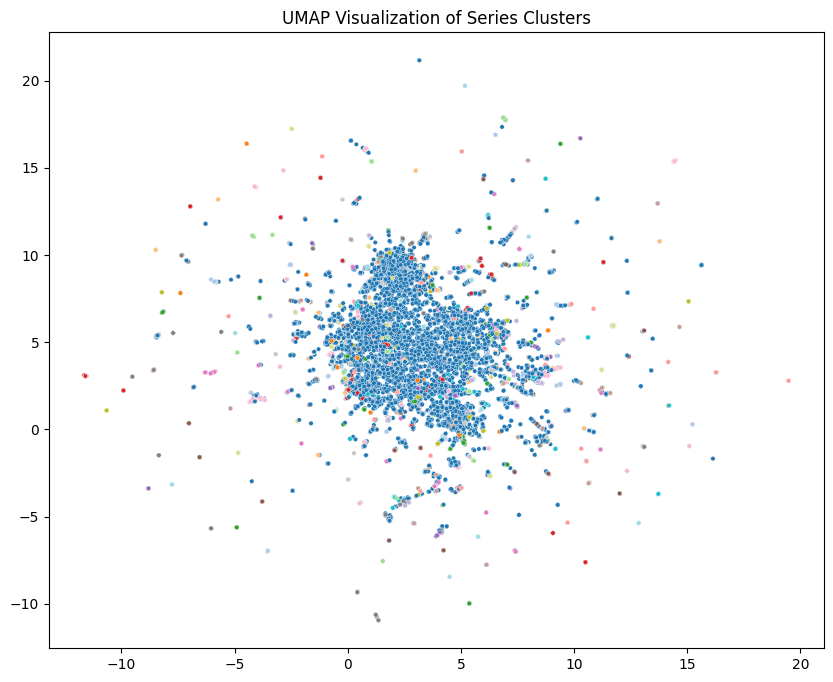

In [93]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce train embeddings to 2D
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

train_2d = reducer.fit_transform(train_emb)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=train_2d[:, 0],
    y=train_2d[:, 1],
    hue=train_labels,
    palette="tab20",
    legend=False,
    s=10
)

plt.title("UMAP Visualization of Series Clusters")
plt.show()

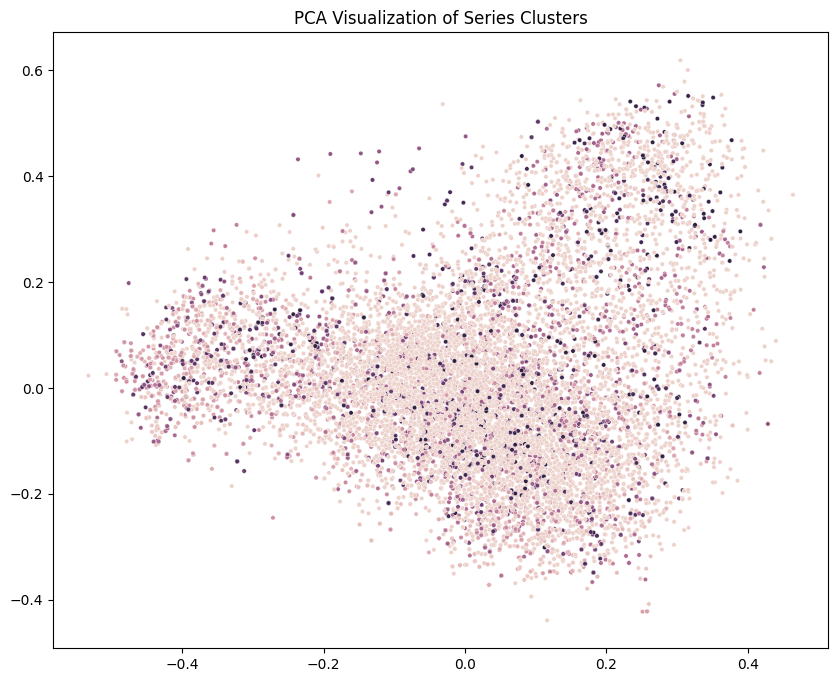

In [94]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
train_2d = pca.fit_transform(train_emb)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=train_2d[:, 0],
    y=train_2d[:, 1],
    hue=train_labels,
    legend=False,
    s=10
)

plt.title("PCA Visualization of Series Clusters")
plt.show()

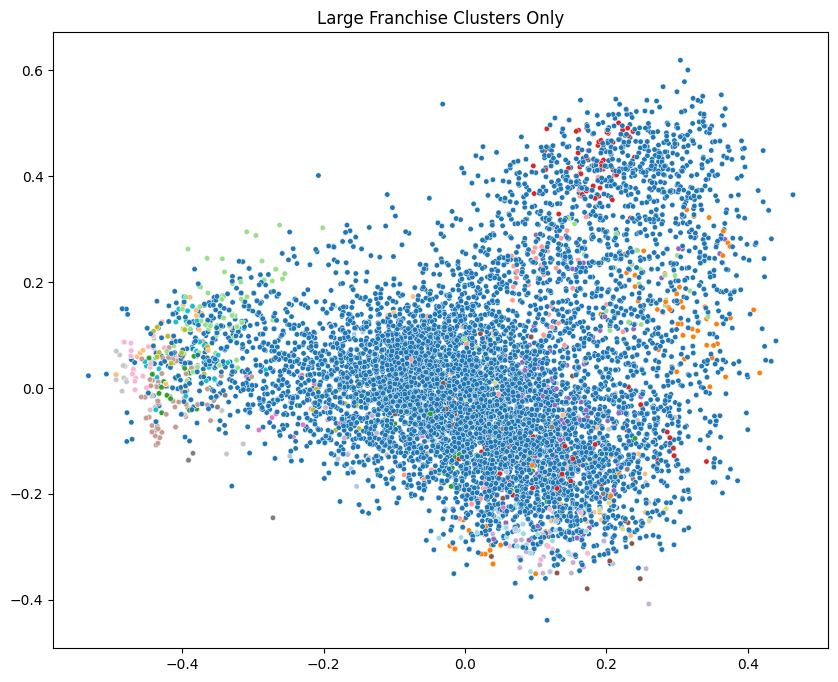

In [95]:
cluster_sizes = pd.Series(train_labels).value_counts()
large_clusters = cluster_sizes[cluster_sizes >= 20].index

mask = np.isin(train_labels, large_clusters)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=train_2d[mask, 0],
    y=train_2d[mask, 1],
    hue=train_labels[mask],
    palette="tab20",
    legend=False,
    s=15
)

plt.title("Large Franchise Clusters Only")
plt.show()

In [96]:
# Redo linear regression model including the series cluster

In [97]:
# Preperation for training: Merge all platform with <50 observations into "Other"

platform_counts = df["Platform"].value_counts()

valid_platforms = platform_counts[platform_counts >= 50].index

# create training platform column
df["Platform_train"] = df["Platform"].where(
    df["Platform"].isin(valid_platforms),
    "Other"
)

# quick check
df["Platform_train"].value_counts()

Platform_train
PS2      2132
DS       2131
PS3      1304
Wii      1295
X360     1235
PSP      1198
PS       1191
PC        939
XB        804
GBA       788
GC        542
3DS       499
PSV       410
PS4       336
N64       316
SNES      239
XOne      213
SAT       173
WiiU      143
2600      119
GB         98
NES        98
Other      58
DC         52
Name: count, dtype: int64

In [98]:
# select relevant columns for training

cols = ["Platform", "Year", "Genre", "Publisher", "Global_Sales", "Series_Cluster"]
df = df[cols].dropna(subset=["Platform", "Year", "Genre", "Publisher", "Global_Sales", "Series_Cluster"]).copy()
df["Year"] = df["Year"].astype(int)

# target (log)
y = np.log1p(df["Global_Sales"])

X = df[["Platform", "Year", "Genre", "Publisher", "Series_Cluster"]]

In [99]:
# 2) train/test split (time-aware to avoid leakage)
# choose a cutoff year; here: last ~3 years in dataset become test
cutoff = df["Year"].quantile(0.95)
cutoff = int(cutoff)

train_mask = df["Year"] < cutoff
test_mask = ~train_mask

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

cutoff, X_train.shape, X_test.shape

(2015, (15354, 5), (959, 5))

In [100]:
# 3) preprocessing: one-hot encode categoricals, scale numeric year
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV

cat_cols = ["Platform", "Genre", "Publisher", "Series_Cluster"]
num_cols = ["Year"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ],
    remainder="drop"
)

# 4) model: Ridge with cross-validated alpha (regularization strength)
alphas = np.logspace(-3, 3, 50)

model = RidgeCV(alphas=alphas, cv=5)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", model)
])


In [101]:
# 5) train
pipe.fit(X_train, y_train)

best_alpha = pipe.named_steps["model"].alpha_
best_alpha

np.float64(1.5264179671752334)

In [102]:
# 6) predict + evaluate (on log scale)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = pipe.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
mae_log = mean_absolute_error(y_test, y_pred)
r2_log = r2_score(y_test, y_pred)

rmse_log, mae_log, r2_log

/opt/anaconda3/envs/ASDA_2025_Group_1_Portfolio_new/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(np.float64(0.3297024007999759), 0.23233367568578467, 0.07101089003393479)

In [103]:
# 7) optional: evaluate in original sales scale (interpretability)
# note: metrics on original scale are dominated by blockbusters; keep log metrics as primary
sales_true = np.expm1(y_test)
sales_pred = np.expm1(y_pred)

rmse_sales = np.sqrt(mean_squared_error(sales_true, sales_pred))
mae_sales = mean_absolute_error(sales_true, sales_pred)
r2_sales = r2_score(sales_true, sales_pred)

rmse_sales, mae_sales, r2_sales

(np.float64(0.810556957436817), 0.400418694830149, 0.20309126490136042)

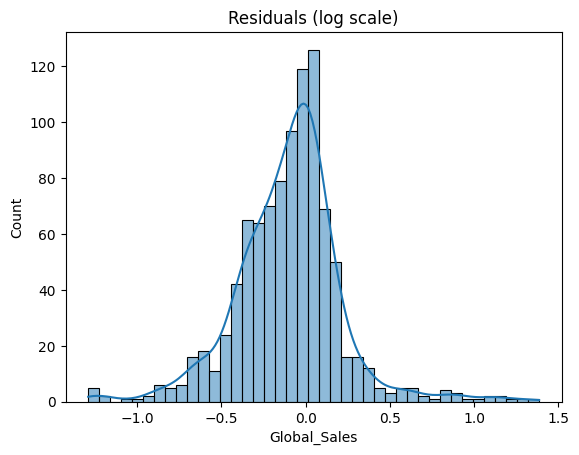

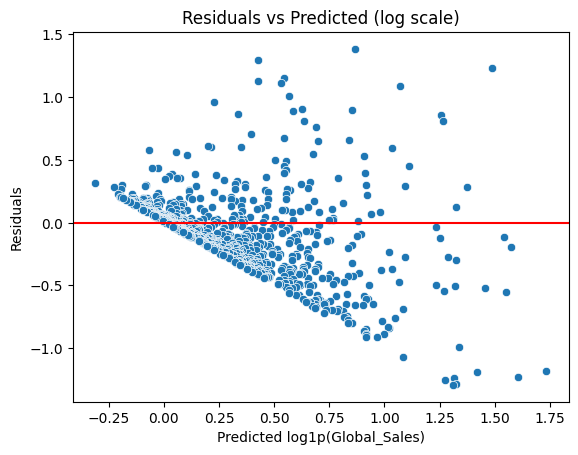

In [104]:
# 8) quick residual diagnostics (log scale)
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residuals (log scale)")
plt.show()

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red")
plt.title("Residuals vs Predicted (log scale)")
plt.xlabel("Predicted log1p(Global_Sales)")
plt.ylabel("Residuals")
plt.show()

In [105]:
# Predict on test set (log scale)
y_pred_log = pipe.predict(X_test)

# Back-transform to original sales scale
y_test_sales = np.expm1(y_test)
y_pred_sales = np.expm1(y_pred_log)

# Absolute + relative errors (original scale)
abs_err = np.abs(y_test_sales - y_pred_sales)
pct_err = abs_err / np.clip(y_test_sales, 1e-9, None)  # avoid divide-by-zero

# Summary metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

rmse_sales = np.sqrt(mean_squared_error(y_test_sales, y_pred_sales))
mae_sales = mean_absolute_error(y_test_sales, y_pred_sales)
r2_sales = r2_score(y_test_sales, y_pred_sales)

print("=== Test Set Performance of Regression with Series Cluster ===\n")

print("LOG SCALE:")
print(f"  RMSE: {rmse_log:.4f} | MAE: {mae_log:.4f} | R2: {r2_log:.4f}")

print("\nORIGINAL SALES SCALE:")
print(f"  RMSE: {rmse_sales:.4f} | MAE: {mae_sales:.4f} | R2: {r2_sales:.4f}")

# Precision-style reporting (robust percentiles)
print("\nABS ERROR (sales) percentiles:")
print(abs_err.quantile([0.5, 0.75, 0.9, 0.95]).to_string())

print("\nPERCENT ERROR percentiles (only where true sales > 0.1):")
mask = y_test_sales > 0.1
print(pct_err[mask].quantile([0.5, 0.75, 0.9, 0.95]).to_string())

# Show worst predictions (largest absolute errors)
results = X_test.copy()
results["true_sales"] = y_test_sales.values
results["pred_sales"] = y_pred_sales
results["abs_err"] = abs_err.values
results["pct_err"] = pct_err.values

results.sort_values("abs_err", ascending=False).head(20)

=== Test Set Performance of Regression with Series Cluster ===

LOG SCALE:
  RMSE: 0.3297 | MAE: 0.2323 | R2: 0.0710

ORIGINAL SALES SCALE:
  RMSE: 0.8106 | MAE: 0.4004 | R2: 0.2031

ABS ERROR (sales) percentiles:
0.50    0.189421
0.75    0.449152
0.90    0.916379
0.95    1.431636

PERCENT ERROR percentiles (only where true sales > 0.1):
0.50    0.709650
0.75    1.467921
0.90    2.983521
0.95    4.499415


/opt/anaconda3/envs/ASDA_2025_Group_1_Portfolio_new/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Platform,Year,Genre,Publisher,Series_Cluster,true_sales,pred_sales,abs_err,pct_err
33,PS4,2015,Shooter,Activision,5,14.24,3.430108,10.809892,0.759122
77,PS4,2015,Sports,Electronic Arts,12,8.49,1.375477,7.114523,0.837989
92,PS4,2015,Shooter,Electronic Arts,65,7.67,1.916519,5.753481,0.750128
101,XOne,2015,Shooter,Activision,5,7.30,2.515882,4.784118,0.655359
109,PS4,2015,Role-Playing,Bethesda Softworks,40,6.96,2.547065,4.412935,0.634042
235,WiiU,2015,Shooter,Nintendo,-1,4.57,0.529371,4.040629,0.884164
2756,3DS,2015,Role-Playing,Nintendo,0,0.74,4.665762,3.925762,5.305084
243,PS4,2015,Action,Sony Computer Entertainment,-1,4.47,0.727268,3.742732,0.837300
4222,3DS,2016,Action,Nintendo,14,0.46,3.988000,3.528000,7.669564
271,PS4,2016,Shooter,Sony Computer Entertainment,-1,4.20,0.704335,3.495665,0.832301


# Performance Analysis of Regression with added Series Clusters:

Adding the Series (franchise) cluster variable leads to a measurable but moderate improvement in predictive performance. On the log scale, R² increases slightly (from approximately 0.064 to 0.071), indicating a small gain in explained variance. On the original sales scale, R² improves more noticeably (from roughly 0.169 to 0.203), suggesting that franchise information contributes meaningfully to explaining variation in absolute sales levels. Error metrics also improve: RMSE and MAE decrease modestly, and the median absolute error drops from about 0.23 million units to roughly 0.19 million units, representing a meaningful reduction in typical prediction error.

Overall, incorporating franchise structure enhances model performance, confirming that series identity contains relevant predictive signal beyond platform, genre, publisher, and year. However, the overall explanatory power remains limited (R² ≈ 0.20 at best), indicating that the available metadata does not capture the primary drivers of commercial success. Sales outcomes are likely influenced by additional factors such as brand strength, marketing intensity, and product quality, which are not present in the dataset.




# Test Set Performance Comparison

## 1) Regression with Series Cluster

### Log Scale
- **RMSE:** 0.3297  
- **MAE:** 0.2323  
- **R²:** 0.0710  

### Original Sales Scale
- **RMSE:** 0.8106  
- **MAE:** 0.4004  
- **R²:** 0.2031  

### Absolute Error (Sales) – Percentiles
| Percentile | Absolute Error |
|------------|----------------|
| 50%        | 0.189421       |
| 75%        | 0.449152       |
| 90%        | 0.916379       |
| 95%        | 1.431636       |

### Percent Error (Sales > 0.1) – Percentiles
| Percentile | Percent Error |
|------------|--------------|
| 50%        | 0.709650     |
| 75%        | 1.467921     |
| 90%        | 2.983521     |
| 95%        | 4.499415     |

---

## 2) Regression (Baseline)

### Log Scale
- **RMSE:** 0.3266  
- **MAE:** 0.2402  
- **R²:** 0.0886  

### Original Sales Scale
- **RMSE:** 0.8342  
- **MAE:** 0.4022  
- **R²:** 0.1560  

### Absolute Error (Sales) – Percentiles
| Percentile | Absolute Error |
|------------|----------------|
| 50%        | 0.226062       |
| 75%        | 0.505470       |
| 90%        | 0.802053       |
| 95%        | 1.004832       |

### Percent Error (Sales > 0.1) – Percentiles
| Percentile | Percent Error |
|------------|--------------|
| 50%        | 0.704845     |
| 75%        | 1.377703     |
| 90%        | 3.204151     |
| 95%        | 4.316639     |